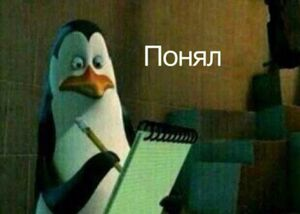

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("art_daily_jumpsup.csv")

df.head()

,timestamp,value
0,2014-04-01 00:00:00,19.761252
1,2014-04-01 00:05:00,20.500833
2,2014-04-01 00:10:00,19.961641
3,2014-04-01 00:15:00,21.490266
4,2014-04-01 00:20:00,20.187739


Обработка

In [ ]:

df['timestamp'] = pd.to_datetime(df['timestamp'])

df = df.sort_values('timestamp')

df.set_index('timestamp', inplace=True)
print("Размер датасета:", df.shape)
print("\nТипы данных:")
print(df.dtypes)

print("\nКоличество пропусков:")
print(df.isnull().sum())

print("\nКоличество дубликатов:", df.duplicated().sum())
df = df.dropna()

print("\nПервые строки после обработки:")
display(df.head())

Размер датасета: (4032, 1)

Типы данных:
value    float64
dtype: object

Количество пропусков:
value    0
dtype: int64

Количество дубликатов: 0

Первые строки после обработки:


,value
timestamp,
2014-04-01 00:00:00,19.761252
2014-04-01 00:05:00,20.500833
2014-04-01 00:10:00,19.961641
2014-04-01 00:15:00,21.490266
2014-04-01 00:20:00,20.187739


In [ ]:
df.describe()

,value
count,4032.000000
mean,44.494254
std,32.432473
min,18.001010
25%,19.991382
50%,21.648503
75%,76.435943
max,164.947481


Рисуем

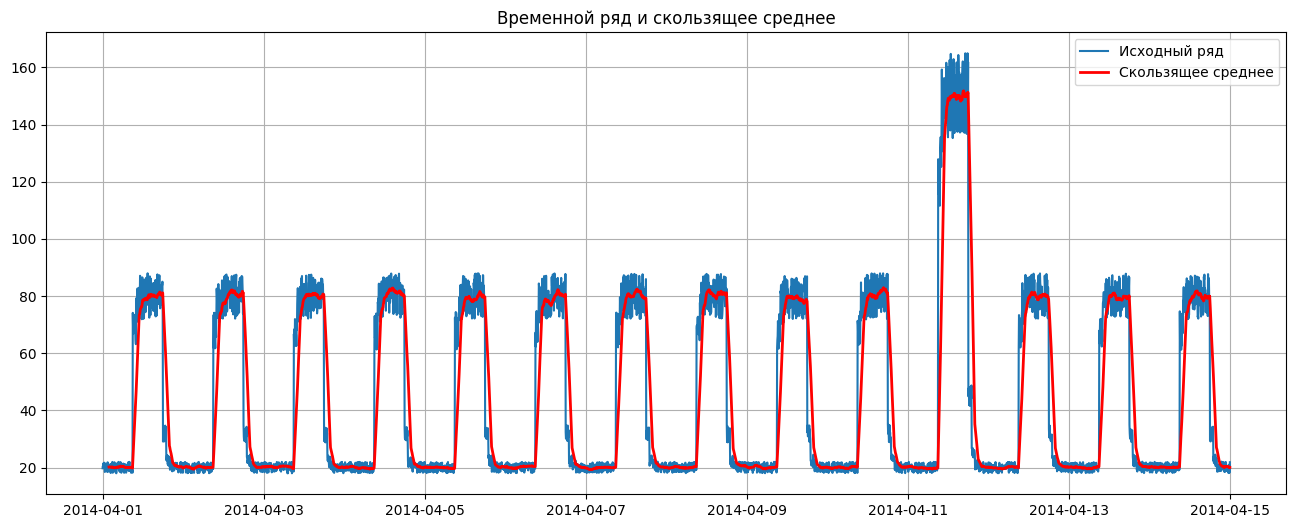

In [ ]:
window = 24

df['RollingMean'] = df['value'].rolling(window=window).mean()
df['RollingStd'] = df['value'].rolling(window=window).std()

plt.figure(figsize=(16,6))

plt.plot(df.index,
         df['value'],
         label='Исходный ряд')

plt.plot(df.index,
         df['RollingMean'],
         color='red',
         linewidth=2,
         label='Скользящее среднее')

plt.title('Временной ряд и скользящее среднее')

plt.grid(True)
plt.legend()

plt.show()

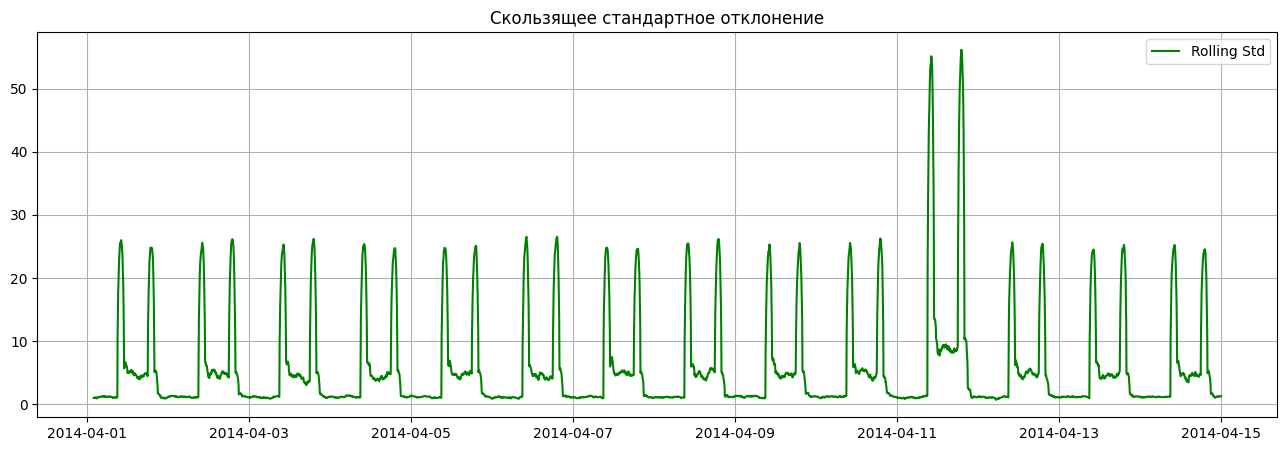

In [ ]:
plt.figure(figsize=(16,5))

plt.plot(df.index,
         df['RollingStd'],
         color='green',
         label='Rolling Std')

plt.title('Скользящее стандартное отклонение')

plt.grid(True)
plt.legend()

plt.show()

На графике хорошо прослеживается динамика временного ряда. Большая часть наблюдений изменяется плавно и имеет выраженную периодичность. Скользящее среднее сглаживает кратковременные колебания и позволяет лучше увидеть общий тренд. Скользящее стандартное отклонение показывает изменение разброса значений во времени. Между 11 и 13 апреля заметен резкий скачок значений, который потенциально может рассматриваться как аномалия.

In [ ]:
model_df = df[['value']].copy()

model_df['lag1'] = model_df['value'].shift(1)
model_df['lag2'] = model_df['value'].shift(2)
model_df['lag3'] = model_df['value'].shift(3)

model_df = model_df.dropna()

model_df.head()

,value,lag1,lag2,lag3
timestamp,,,,
2014-04-01 00:15:00,21.490266,19.961641,20.500833,19.761252
2014-04-01 00:20:00,20.187739,21.490266,19.961641,20.500833
2014-04-01 00:25:00,19.923126,20.187739,21.490266,19.961641
2014-04-01 00:30:00,21.698404,19.923126,20.187739,21.490266
2014-04-01 00:35:00,20.878758,21.698404,19.923126,20.187739


In [ ]:
from sklearn.model_selection import train_test_split

X = model_df[['lag1','lag2','lag3']]
y = model_df['value']

split = int(len(model_df)*0.7)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
pred_2 = model.predict(X_train)
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae_l = mean_absolute_error(y_test, pred)
rmse_l = np.sqrt(mean_squared_error(y_test, pred))

print("MAE =", round(mae_l,3))
print("RMSE =", round(rmse_l,3))

MAE = 3.362
RMSE = 7.33


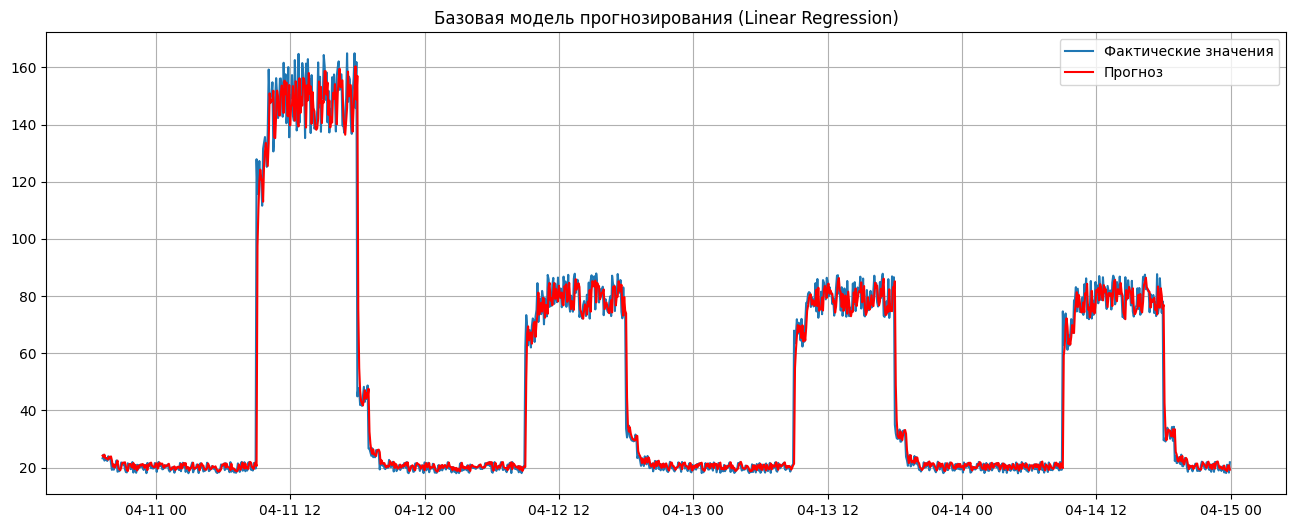

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(y_test.index,
         y_test,
         label='Фактические значения')

plt.plot(y_test.index,
         pred,
         color='red',
         label='Прогноз')

plt.title('Базовая модель прогнозирования (Linear Regression)')

plt.grid(True)
plt.legend()

plt.show()

В качестве базовой модели была использована линейная регрессия с лаговыми признаками. Для прогнозирования текущего значения использовались три предыдущих наблюдения временного ряда. Данные были разделены на обучающую (70%) и тестовую (20%) выборки без перемешивания, что позволяет сохранить временную структуру данных. После обучения модели были рассчитаны метрики MAE и RMSE, а также построен график сравнения фактических и прогнозных значений. Полученные результаты будут использованы в дальнейшем для сравнения с более сложной моделью прогнозирования (SARIMA).

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0827 - val_loss: 0.0121
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0092 - val_loss: 0.0102
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0090 - val_loss: 0.0097
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0089 - val_loss: 0.0098
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0087 - val_loss: 0.0095
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0086 - val_loss: 0.0094
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0085 - val_loss: 0.0094
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0084 - val_loss: 0.0090
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0084 - val_loss: 0.0089
Epoch 10/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0081 - val_loss: 0.0088
Epoch 11/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0080 - val_loss: 0.0086
Epoch 12/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0079 - val_lo

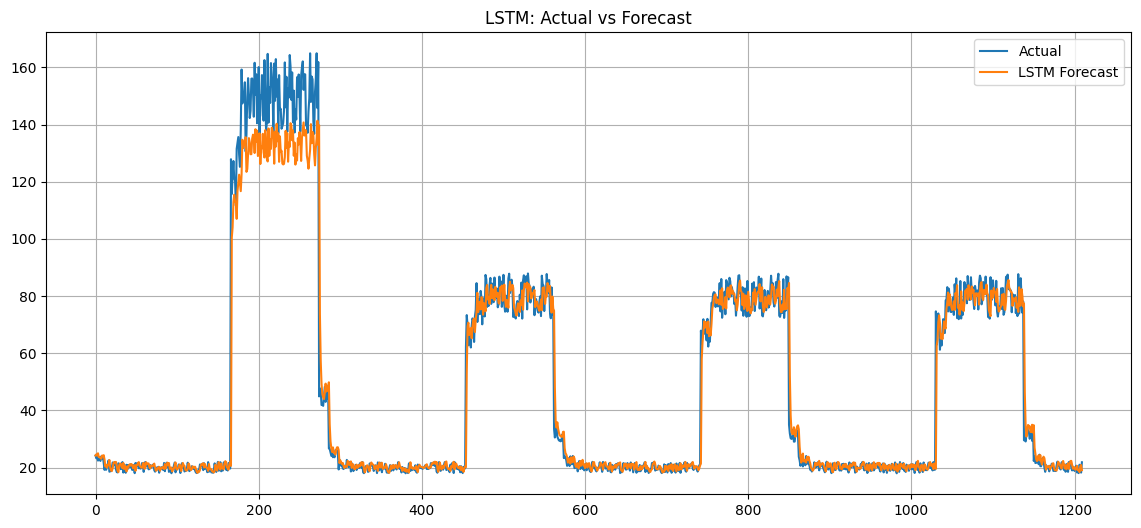

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

series = df['value'].values.reshape(-1,1)

split = int(len(series)*0.7)

train = series[:split]
test = series[split:]

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

look_back = 3

def create_dataset(data, look_back):
    X = []
    y = []

    for i in range(len(data)-look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])

    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_scaled, look_back)

test_all = np.vstack((train_scaled[-look_back:], test_scaled))

X_test, y_test = create_dataset(test_all, look_back)

model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(look_back,1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


pred_scaled = model.predict(X_test)

pred = scaler.inverse_transform(pred_scaled)
y_true = scaler.inverse_transform(y_test)


mae = mean_absolute_error(y_true, pred)
rmse = np.sqrt(mean_squared_error(y_true, pred))

print(f"MAE = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")

plt.figure(figsize=(14,6))

plt.plot(y_true, label='Actual')
plt.plot(pred, label='LSTM Forecast')

plt.title("LSTM: Actual vs Forecast")
plt.legend()
plt.grid(True)

plt.show()

Количество аномалий: 12


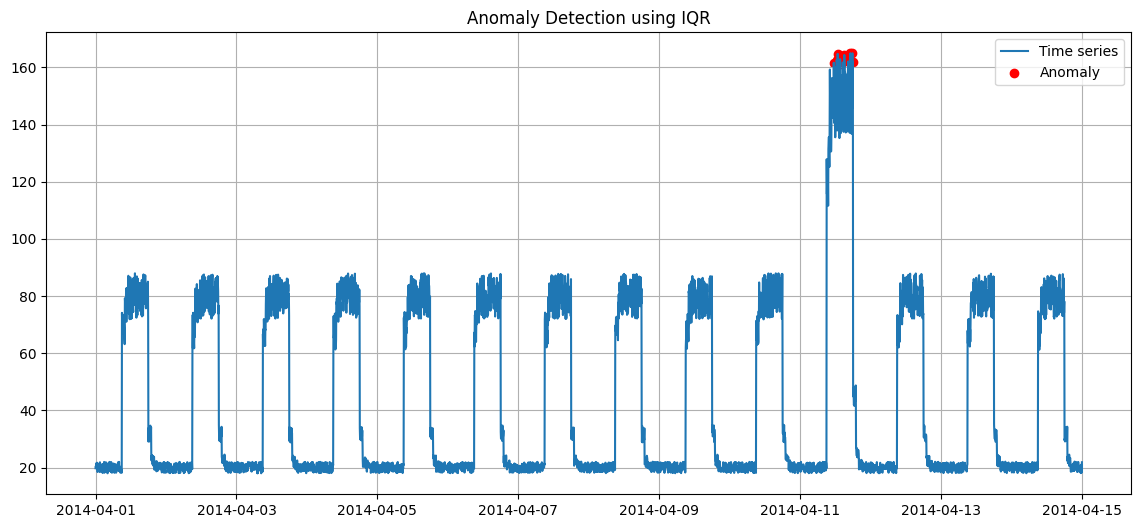

In [ ]:
import matplotlib.pyplot as plt

Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

anomalies_iqr = df[(df['value'] < lower) | (df['value'] > upper)]

print("Количество аномалий:", len(anomalies_iqr))

plt.figure(figsize=(14,6))

plt.plot(df.index, df['value'], label='Time series')
plt.scatter(
    anomalies_iqr.index,
    anomalies_iqr['value'],
    color='red',
    label='Anomaly'
)

plt.title("Anomaly Detection using IQR")
plt.legend()
plt.grid(True)
plt.show()

Количество аномалий: 24


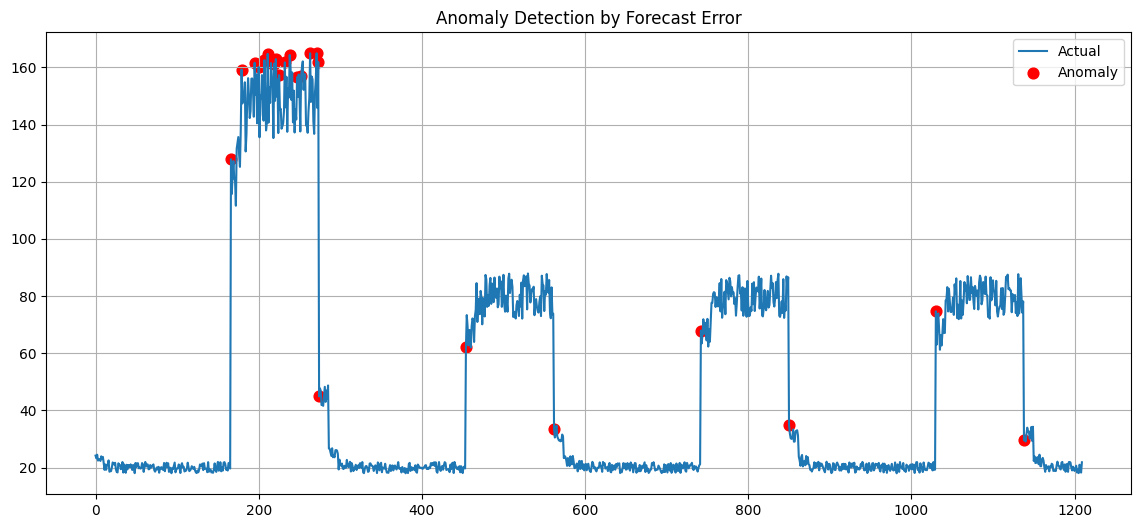

In [ ]:
errors = np.abs(y_true.flatten() - pred.flatten())
threshold = errors.mean() + 3 * errors.std()

anomaly_idx = np.where(errors > threshold)[0]

print("Количество аномалий:", len(anomaly_idx))
plt.figure(figsize=(14,6))

plt.plot(y_true, label='Actual')

plt.scatter(
    anomaly_idx,
    y_true[anomaly_idx],
    color='red',
    s=60,
    label='Anomaly'
)

plt.title("Anomaly Detection by Forecast Error")
plt.legend()
plt.grid(True)
plt.show()

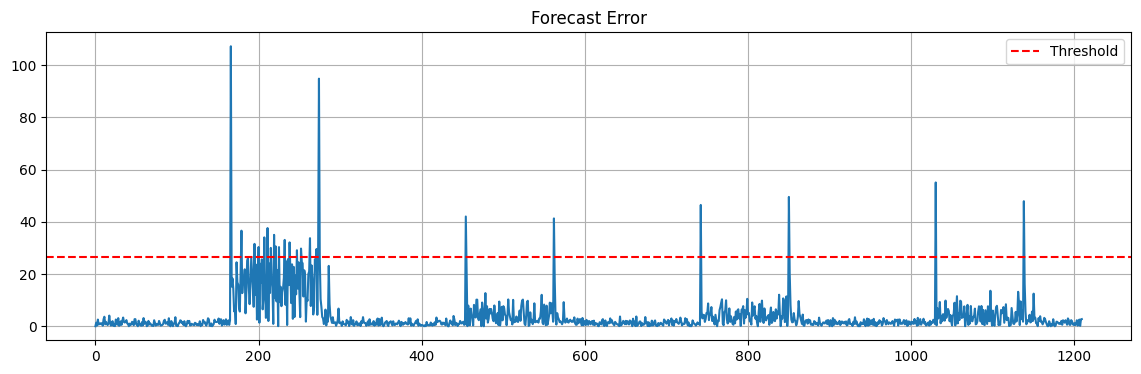

In [ ]:
plt.figure(figsize=(14,4))

plt.plot(errors)

plt.axhline(
    threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)

plt.title("Forecast Error")
plt.legend()
plt.grid(True)

plt.show()